# Processing of 2D NMR Data with ``NMRflux``

In [1]:
import Pkg; Pkg.activate(".")

using Plots
using NMRflux

theme(:solarized)

default(size=(600,400),
        tick_direction=:out,
        framestyle=:box,
        margin=(6,:mm),
        legendfontsize=8,
        guidefontsize=10,
        tickfontsize=10,
        fontfamily="Helvetica", 
        fmt=:svg,dpi=100)

  Activating project at `~/Dropbox/Source/NMRflux.jl/demo`


In [2]:
NMRflux.Examples.Data["SH3 domain HSQC"]["files"]

5-element Vector{String}:
 "/Users/mu3q/Dropbox/Source/NMRf" ⋯ 59 bytes ⋯ "3-test_15n_hsqc_dec_pn-1-1.jdf"
 "/Users/mu3q/Dropbox/Source/NMRf" ⋯ 52 bytes ⋯ "-15N-SH3-test_1d_1h_wg-1-1.jdf"
 "/Users/mu3q/Dropbox/Source/NMRf" ⋯ 58 bytes ⋯ "H3-test_E1d_15nhsqc_wg-1-1.jdf"
 "/Users/mu3q/Dropbox/Source/NMRf" ⋯ 58 bytes ⋯ "H3-test_E2d_15nhsqc_wg-1-1.jdf"
 "/Users/mu3q/Dropbox/Source/NMRf" ⋯ 63 bytes ⋯ "st_het_sofast_hmqc_pfg-1-1.jdf"

In [3]:
params,fid2 = load(NMRflux.Examples.Data["SH3 domain HSQC"]["files"][1],:JEOL)
fid2

(1280, 256, 4) SpectData Array{Float64, 3} with coords:(0.0:0.00013328:0.17046512, 0.0:0.00016440000000000004:0.04192200000000001, 1:4)

In [4]:
fid2[:,1,4] isa NMRflux.SpectData{<:Number,1}

true

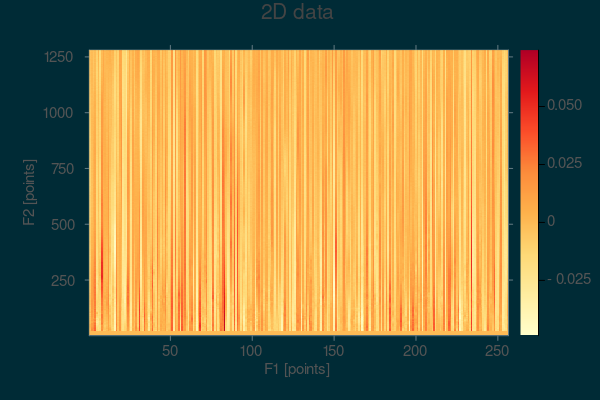

In [5]:
heatmap(fid2[:,:,1],title="2D data",xlabel="F1 [points]",ylabel="F2 [points]")

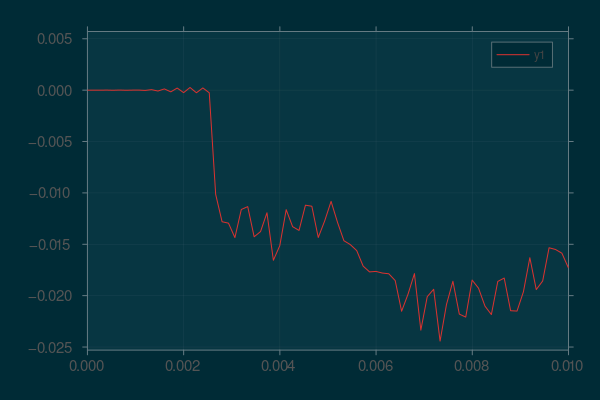

In [29]:
a=fid2[:,1,4]

plot(a,xlims=[0,0.01])

In [7]:
methods(plot)

# 5 methods for generic function "plot" from RecipesBase:
 [1] plot(A::SpectData{<:Number, 1}, args...; kwargs...)
     @ ~/Dropbox/Source/NMRflux.jl/ext/PlotsExt.jl:8
 [2] plot(plt1::Plots.Plot, plt2::Union{Plots.PlaceHolder, Plots.Plot}, plts_tail::Union{Plots.PlaceHolder, Plots.Plot}...; kw...)
     @ ~/.julia/packages/Plots/h49MV/src/plot.jl:107
 [3] plot(plt::Plots.Plot, args...; kw...)
     @ ~/.julia/packages/Plots/h49MV/src/plot.jl:206
 [4] plot(sp::Plots.Subplot, args...; kw...)
     @ ~/.julia/packages/Plots/h49MV/src/plot.jl:290
 [5] plot(args...; kw...)
     @ ~/.julia/packages/Plots/h49MV/src/plot.jl:93

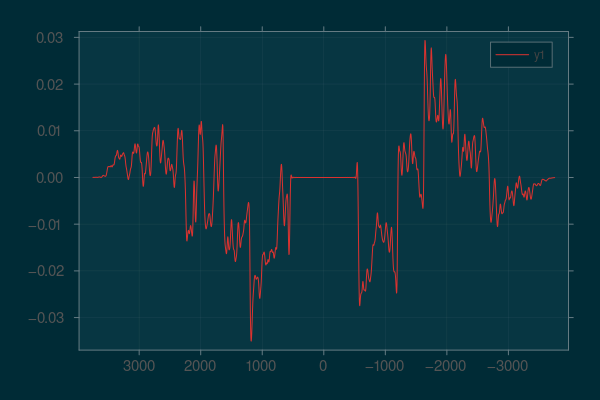

In [101]:
δt = step(NMRflux.coords(fid2,1))

process_x = Chain(
 ZeroFill([2048,512]),
 DigitalFilter(BandReject(-0.075,0.075,256)),
 Apodize(R=30.0pi),
 FourierTransform(),
 PhaseCorrect(ph0=0.2pi,ph1=2pi*(0.0023+256*δt)),
 # AutoPhaseCorrectChen()
)

process_y = Chain(
    FourierTransform(dim=2)
)


xf1r =   (fid2[:,:,1]-im*fid2[:,:,2])  |> process_x
xf1i =   (fid2[:,:,3]-im*fid2[:,:,4])  |> process_x

xf2 =  real(xf1r)-im*real(xf1i)  |> process_y


plot((xf2[:,256]),xaxis=:flip)
# plot!((xf1i[:,1]),xaxis=:flip)


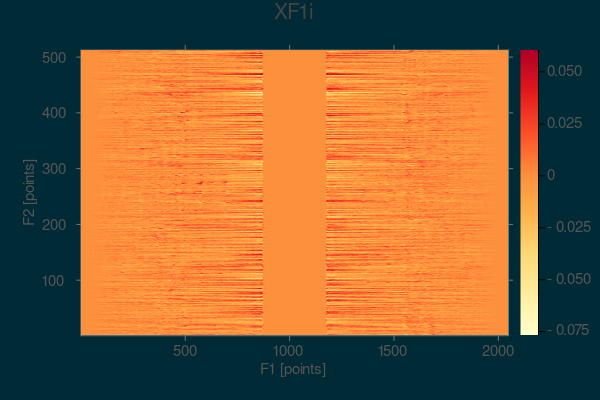

In [103]:
heatmap(transpose(real.(xf2)),title="XF1i",xlabel="F1 [points]",ylabel="F2 [points]")

In [74]:
io = open(NMRflux.Examples.Data["SH3 domain HSQC"]["files"][5],"r")
header,params,data=NMRflux.FileIO.readJEOL(io)
close(io)

In [10]:
[header[k] for k in ["dims","dataPoints","dataAxisType","dataAxisStop","dataType","dataFormat","dims"]]

7-element Vector{Any}:
 2
  Int32[1392, 24, 1, 1, 1, 1, 1, 1]
  ["Complex", "Complex", "None", "None", "None", "None", "None", "None"]
  [0.18516992000000002, 0.00995164, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  Float64
  "Small_Three_D"
 2

In [11]:
show(stdout, MIME("text/plain"), header)    

Dict{String, Any} with 43 entries:
  "listLength" => UInt32[0x00000000, 0x00000000, 0x00000000, 0x00000000, 0x00000000, 0x00000000, 0x00000000, 0x00000000]
  "baseFreq" => [600.172, 60.8149, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  "author" => "Veronika"
  "annotateLength" => 0x00000000
  "contextLength" => 0x00005b10
  "dataAxisStop" => [0.18517, 0.00995164, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  "instrument" => "ECA"
  "dataPoints" => Int32[1392, 24, 1, 1, 1, 1, 1, 1]
  "totalSize" => 0x0000000000110b40
  "annotationOk" => true
  "dataType" => Float64
  "historyLength" => 0x00000000
  "listStart" => UInt32[0x00005720, 0x00005720, 0x00005720, 0x00005720, 0x00005720, 0x00005720, 0x00005720, 0x00005720]
  "dataLength" => 0x0000000000105000
  "comment" => "het_sofast_hmqc_pfg"
  "historyUsed" => 0x00000000
  "dataFormat" => "Small_Three_D"
  "nodeName" => "scc"
  "paramStart" => 0x00000550
  "dataOffsetStart" => Int32[0, 0, 0, 0, 0, 0, 0, 0]
  "site" => "NM-70070G6"
  "dataAxisTitle" => SubString{String

In [13]:
show(stdout, MIME("text/plain"), params)

Dict{String, Any} with 331 entries:
  "sawtooth_range" => (0, Tuple{String, String, Int8}[("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0)], 4.0)
  "shape_factor" => (0, Tuple{String, String, Int8}[("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0)], 0.0)
  "obs_atn" => (0, Tuple{String, String, Int8}[("", "Decibel", 1), ("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0)], 8.9)
  "lowIndex" => 0x00000000
  "changer_slot_position" => (0, Tuple{String, String, Int8}[("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0)], 0.0)
  "Y_PRESCANS" => (0, Tuple{String, String, Int8}[("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0)], 0)
  "get_value_of_field" => (0, Tuple{String, String, Int8}[("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0), ("", "None", 0)], "pulse_service::g")
  "TOTAL_SCANS" => (0, Tuple{String, String, Int8}[("

In [ ]:
length(data)./4

In [ ]:
1280*256

In [ ]:
plot(data[1:64])

In [ ]:

heatmap(reshape(data[(40*32*32) .+ (1:32*32)],32,32),title="2D data",xlabel="F1 [points]",ylabel="F2 [points]")

In [ ]:
A = reshape(data,32,32,40,8,4) ;
section1 = [A[:,:,k,l,m] for k=1:40, l=1:8, m=1:4]
S1=reshape(vcat(section1...),1280,256,4)
heatmap(S1[:,:,2],title="2D data",xlabel="F1 [points]",ylabel="F2 [points]")

In [ ]:
FID2=SpectData(S1,())

In [ ]:
plot(S1[:,13,title="FID",xlabel="Time [s]",ylabel="Amplitude [a.u.]")

In [ ]:
strides(A)

In [ ]:
A[:,:,1:2,1,1]

In [ ]:
section = zeros(Float64, 1280, 256

me = 32 
row1 = [ data[ k:k+me-1] for k=1:40:  